# Estudio de métodos aproximados para el aprendizaje por refuerzo en entornos continuos

## Introducción

## Preparación del entorno

In [1]:
# Librerías necesarias para el setup
import sys, os

En función de si el notebook se va a ejecutar en Colab o en local, dentro del repositorio clonado, se deberá ejecutar una de las dos siguientes secciones. 

### Ejecución en Colab

In [2]:
# Clonar el repositorio

In [3]:
# Añadir los directorio fuentes al path de Python

### Ejecución en local

In [4]:
# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv', '', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv\\Lib\\site-packages', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\entornos_complejos\\src']


### Importación de librerías y módulos

In [5]:
import gymnasium as gym
import numpy as np

from agents import Agent
import random
import imageio 
from policies import EpsilonGreedyPolicy, EpsilonDecayPolicy
from learners import SARSASemiGradient, DQNLearner, QNetwork
from plotting import plotting
import matplotlib.pyplot as plt

## Entorno de Gymnasium

Notas:

Debe ser un entorno cuyo espacio de observaciones sea **continuo**. Una opción podría ser el entorno [*Cart Pole*](https://gymnasium.farama.org/environments/classic_control/cart_pole/), pero hay que tener cuidado al discretizarlo para SARSA semi-gradiente porque las velocidades lineal y angular no están acotadas (van de -inf a +inf), así que imagino que tendremos que elegir nosotros un valor mínimo y máximo apropiado. En [este](https://github.com/ldaniel-hm/eml_approximate/blob/main/SolucionDeepSARSA_CartPole.ipynb) notebook se indica como generar una animación del Cart Pole.

En cuanto a las formas de discretizar, podemos empezar por el tile coding porque ya está implementado en el [notebook del profesor](https://github.com/ldaniel-hm/eml_approximate/blob/main/Dos_formas_de_discretizar_espacios_continuos.ipynb), pero quizás estaría bien posteriormente probar con otros métodos de discretización que se comentan en el power point de "Predicción On Policy con Aproximaciones" (Fourier, codificación gruesa, etc.).

Para implementar el discretizador, como se dice en el notebook del profesor, habría que crear una clase que herede de gym.ObservationWrapper. Podríamos hacer un nuevo módulo para meter ahí los discretizadores, en caso de que hagamos varios.

En cuanto a Deep Q-Learning, además de probar con el método estándar, podríamos implementar también Doble Deep Q-Learning y compararlos.

Es posible que en estos nuevos Learners haya que incluir una property ``qtable`` para poder usar la misma clase Agent sin tener que modificarla. Lo ideal sería adaptar estas nuevas clases para hacer el mínimo número de cambios posible. 

:)

In [9]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()

(array([-0.02213516, -0.01547313, -0.02811053, -0.03590687], dtype=float32),
 {})

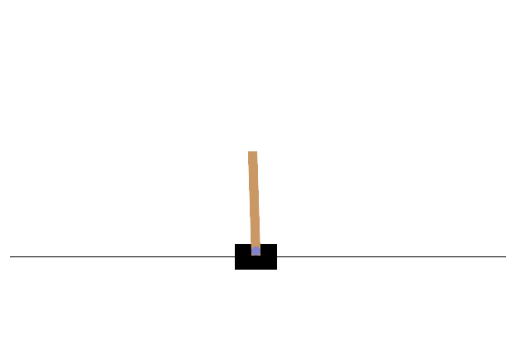

In [10]:
frame = env.render()

plt.imshow(frame)
plt.axis("off")
plt.show()

In [11]:
class TileCodingEnv(gym.ObservationWrapper):
    """    
    CartPole Observation Space (4 dimensiones):
    - Cart Position:        [-4.8,   4.8]
    - Cart Velocity:        [-inf,   inf]  -> acotado a [-3.0, 3.0]
    - Pole Angle:           [-0.418, 0.418] radianes (+-24°)
    - Pole Angular Velocity:[-inf,   inf]  -> acotado a [-3.0, 3.0]
    """

    def __init__(self, env, bins, low, high, n=4):
        """
        Parámetros:
        - env:  Entorno original de gymnasium.
        - bins: Array con el número de intervalos por dimensión.  Shape: (4,)
        - low:  Array con las cotas inferiores de cada dimensión.    Shape: (4,)
        - high: Array con las cotas superiores de cada dimensión.    Shape: (4,)
        - n:    Número de tillings (default 4).
        
        Si usamos CartPole con bins=[8,8,8,8] y n=4 tilings:
        -> el vector observacional tiene 4 dimensiones x 4 tilings = 16 componentes
        -> cada componente es un índice entero comprendido entre [0, bins[d]]
        """
        super().__init__(env)
        self.low = low
        self.high = high
        self.tilings = self._create_tilings(bins, high, low, n)
        # MultiDiscrete: un valor discreto por pareja (dimension x tiling)
        # ejemplo básico: bins=[8,8,8,8], n=4 -> nvec tiene 16 entradas, cada una en el rango [0,8]
        self.observation_space = gym.spaces.MultiDiscrete(nvec=bins.tolist() * n)

    def observation(self, obs):  # Es necesario sobreescribir este método de ObservationWrapper
        """
        Transforma una observación continua en una representación discreta usando tile coding.

        Parámetro:
        - obs: observación continua proveniente del entorno.

        Para cada tiling (rejilla) en self.tilings, se determina el índice del tile en el que
        cae cada componente de la observación mediante np.digitize. Se devuelve una lista de
        tuplas de índices, una por cada tiling.
        """
        indices = []  # Lista que almacenará los índices discretizados para cada tiling.
        for t in self.tilings:
            # Para cada tiling 't', se calcula el índice en el que se encuentra cada componente de la observación.
            tiling_indices = tuple(np.digitize(i, b) for i, b in zip(obs, t))
            indices.append(tiling_indices)  # Se agrega la tupla de índices correspondiente a la tiling actual.
        return indices  # Retorna la lista de índices de todas las tilings.

    def _create_tilings(self, bins, high, low, n):
        """
        Crea n offset tilings para el CartPole de estados de dimensión 4D

        Para 4 dimensiones: displacement_vector = [1,3,5,7]
        Esto garantiza que cada tiling se desplace de manera diferente en cada dimensión.

        Parameters:
        - bins: [n_cart_pos, n_cart_vel, n_pole_angle, n_pole_ang_vel]
        - high: [max_cart_pos, max_cart_vel, max_pole_angle, max_pole_ang_vel]
        - low:  [min_cart_pos, min_cart_vel, min_pole_angle, min_pole_ang_vel]
        - n:    Number of tilings

        Returns:
        - tilings: lista de n tilings. Cada tiling es una lista de 4 arrays de buckets
        """
        # Para 4 dims: np.arange(1, 2*4, 2) -> [1, 3, 5, 7]
        # Dim 0 (cart_pos)       desplazar en multiplos de 1
        # Dim 1 (cart_vel)       desplazar en multiplos de 3
        # Dim 2 (pole_angle)     desplazar en multiplos de 5
        # Dim 3 (pole_ang_vel)   desplazar en multiplos de 7
        displacement_vector = np.arange(1, 2 * len(bins), 2)  # [1, 3, 5, 7]

        tilings = []
        for i in range(1, n + 1):
            # De forma aleatoria se perturban los bordes ligeramente (+-20%) para evitar los artefactos de los bordes
            low_i  = low  - random.random() * 0.2 * np.abs(low)
            high_i = high + random.random() * 0.2 * np.abs(high)

            # Patrón del offset para el tilling i (mod n mantiene valores en el rango de [0, n-1]):
            # i=1: [1,3,5,7] % 4 = [1,3,1,3]
            # i=2: [2,6,10,14] % 4 = [2,2,2,2]
            # i=3: [3,9,15,21] % 4 = [3,1,3,1]
            # i=4: [4,12,20,28] % 4 = [0,0,0,0]
            displacements = displacement_vector * i % n

            # Escalamos los offsets a valores en unidades reales: una unidad = tamaño_segmentpo/n
            segment_sizes = (high_i - low_i) / bins
            displacements = displacements * (segment_sizes / n)

            low_i  += displacements
            high_i += displacements

            # Creamos los bin edges para cada una de las 4 dimensiones
            # np.linspace con (bins[d]-1) puntos crea bins[d] intervalso.
            buckets_i = [np.linspace(j, k, l - 1)
                         for j, k, l in zip(low_i, high_i, bins)]
            tilings.append(buckets_i)

        return tilings

In [12]:
def make_tile_feature_fn(bins, n_tilings, n_actions):
    """
    Construye la feature_fn compatible con SARSASemiGradient.
    
    El vector de features x(s, a) es binario y disperso:
    - n_tilings bloques, uno por tiling
    - Dentro de cada bloque, n_actions sub-bloques
    - Solo el tile activo en cada tiling se activa (= 1.0)
    
    Dimensión total: n_tilings x prod(bins) x n_actions
    """
    tiles_per_tiling = int(np.prod(bins))          # 8^4 = 4096
    block_size       = tiles_per_tiling * n_actions # 4096 × 2 = 8192
    total_dim        = n_tilings * block_size       # 4 × 8192 = 32768

    def flat_tile_index(tiling_indices, bins):
        """Convierte una tupla de índices a un único índice plano (row-major)."""
        idx = 0
        for i, (ti, b) in enumerate(zip(tiling_indices, bins)):
            # Clamp para evitar desbordamientos por np.digitize
            ti_clamped = int(np.clip(ti, 0, b - 1))
            idx = idx * b + ti_clamped
        return idx

    def feature_fn(state, action):
        """
        state  : lista de 4 tuplas [(d0,d1,d2,d3), ...], una por tiling
        action : int  (0 ó 1 en CartPole)
        
        Devuelve vector binario de longitud total_dim.
        """
        x = np.zeros(total_dim)

        for t_idx, tiling_indices in enumerate(state):
            tile_idx   = flat_tile_index(tiling_indices, bins)
            # Offset: bloque del tiling + sub-bloque de la acción
            offset     = t_idx * block_size + action * tiles_per_tiling + tile_idx
            x[offset]  = 1.0

        return x

    return feature_fn, total_dim

In [13]:
bins = np.array([8, 8, 8, 8])
low  = np.array([-4.8, -3.0, -0.418, -3.0])
high = np.array([ 4.8,  3.0,  0.418,  3.0])

base_env = gym.make("CartPole-v1")
env = TileCodingEnv(base_env, bins=bins, low=low, high=high, n=4)

n_tilings = 4
n_actions = env.action_space.n # 2

In [14]:
feature_fn, state_size = make_tile_feature_fn(
    bins = bins,
    n_tilings = n_tilings,
    n_actions = n_actions
)

policy = EpsilonGreedyPolicy(epsilon=0.1)

In [15]:
learner_sarsasemigradient = SARSASemiGradient(
    state_size = state_size,   # 4 x 4096 x 2 = 32768
    action_size = n_actions,
    alpha = 0.1 / n_tilings,   # <- escalar alpha por n_tilings
    gamma = 0.99,
    policy = policy,
    feature_fn = feature_fn
)

In [16]:
agent_sarsasemigradient = Agent(env, learner_sarsasemigradient, policy)

In [17]:
def run_episode_greedy(env, agent_learner, max_steps=500):
    """
    Ejecuta un episodio usando la política greedy y captura los fotogramas.

    Parámetros:
      - env: Entorno Gymnasium configurado con render_mode='rgb_array'.
      - q_network: Red neuronal QNetwork con los pesos cargados.
      - max_steps (int): Número máximo de pasos a ejecutar en el episodio.

    Retorna:
      - list: Lista de fotogramas (imágenes) capturados durante el episodio.
    """
    frames = []  # Lista para almacenar cada fotograma.

    # Reiniciar el entorno y obtener el estado inicial.
    state, _ = env.reset()
    done = False  # Indicador de finalización del episodio.

    # Ejecutar el episodio hasta max_steps o hasta que el entorno indique que ha terminado.
    for _ in range(max_steps):
        # Capturar el fotograma actual del entorno.
        frame = env.render()
        frames.append(frame)

        # Seleccionar la acción óptima utilizando la función greedy.
        q_vals = agent_learner.q_values(state)
        action = np.argmax(q_vals)

        # Ejecutar la acción en el entorno y obtener el siguiente estado y otros datos.
        next_state, reward, done, truncated, info = env.step(action)
        state = next_state  # Actualizar el estado.

        # Si el episodio ha terminado o se ha truncado, capturar el fotograma final y salir.
        if done or truncated:
            frames.append(env.render())
            break

    return frames

In [18]:
def frames_to_gif(frames, filename="cartpole_sarsa.gif"):
    """
    Crea un archivo GIF a partir de una lista de fotogramas.

    Parámetros:
      - frames (list): Lista de fotogramas (imágenes) capturados del entorno.
      - filename (str): Nombre del archivo GIF resultante.

    Retorna:
      - str: Nombre del archivo GIF creado.
    """
    # Abrir un escritor de GIF con imageio.
    with imageio.get_writer(filename, mode='I') as writer:
        # Agregar cada fotograma al GIF.
        for frame in frames:
            writer.append_data(frame)
    return filename

In [19]:
qtable_sarsasemigradient, rewards_sarsasemigradient, episode_lengths_sarsasemigradient, stats_sarsasemigradient = agent_sarsasemigradient.train(400, 10, 42)

100%|██████████| 10/10 [04:59<00:00, 29.97s/it]


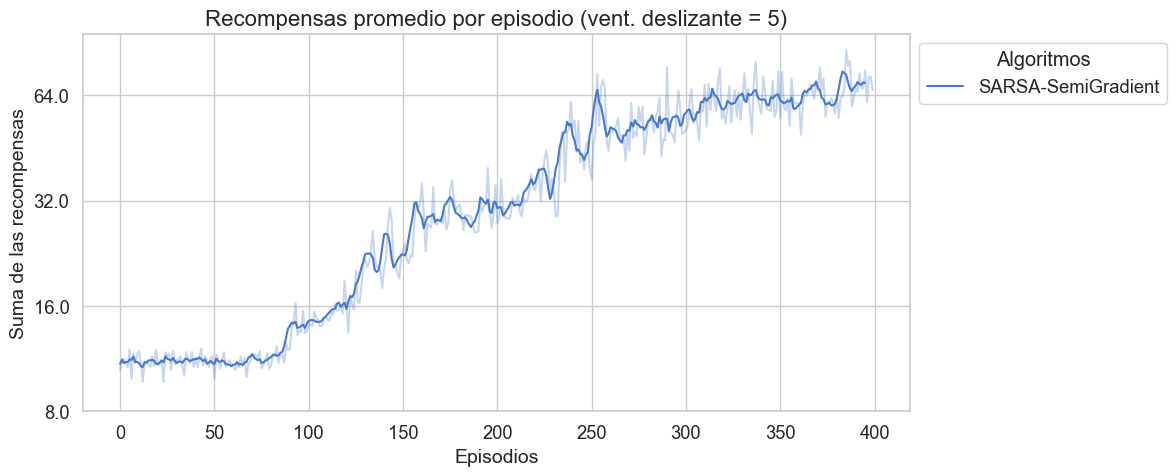

In [20]:
plotting.plot_rewards([rewards_sarsasemigradient],
                      ["SARSA-SemiGradient"],
                      log_scale=True,
                      rolling_window=5)

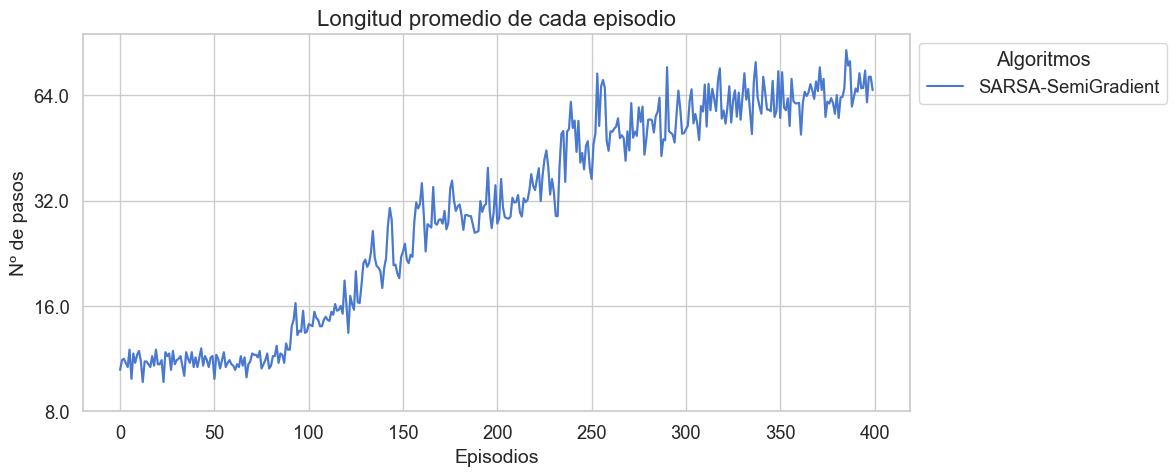

In [21]:
plotting.plot_episode_lengths([episode_lengths_sarsasemigradient],
                                ["SARSA-SemiGradient"],
                                log_scale=True,
                                rolling_window=1)

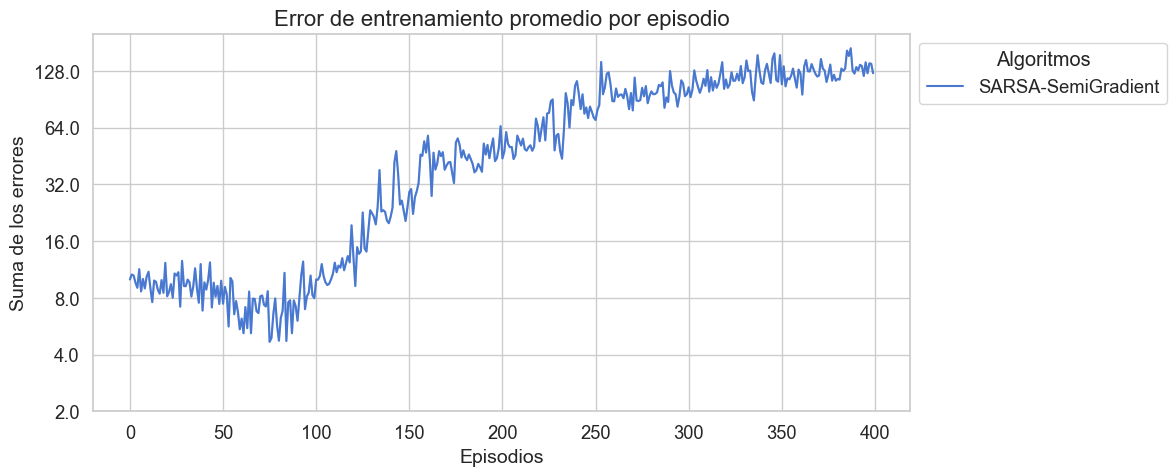

In [22]:
plotting.plot_training_errors([stats_sarsasemigradient['cum_training_error']],
                                ["SARSA-SemiGradient"],
                                log_scale=True,
                                rolling_window=1)

In [31]:
base_env = gym.make("CartPole-v1", render_mode="rgb_array")
env = TileCodingEnv(base_env, bins=bins, low=low, high=high, n=4)

In [32]:
frames = run_episode_greedy(env, learner_sarsasemigradient, max_steps=2000)

In [33]:
env.close()

In [34]:
gif_path = frames_to_gif(frames, filename="cartpole_sarsa.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_sarsa.gif


In [6]:
state_dim = 4  # CartPole: 4 variables de estado.
action_dim = 2  # CartPole: 2 acciones posibles.

In [7]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
net = QNetwork(state_dim=state_dim, action_dim=action_dim, hidden_dim=64)
learner = DQNLearner(state_size=state_dim, action_size=action_dim, q_network=net)
policy = EpsilonGreedyPolicy(epsilon=0.1)
agent = Agent(env, learner, policy)
qtable, rewards, lengths, stats = agent.train(num_episodes=500, n_runs=3)

100%|██████████| 3/3 [20:53<00:00, 417.77s/it]


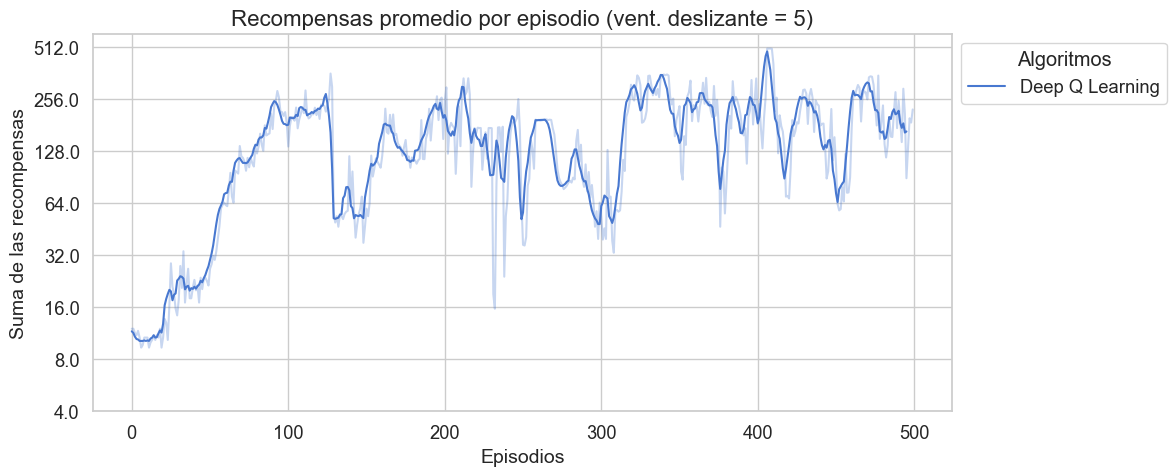

In [8]:
plotting.plot_rewards([rewards],
                      ["Deep Q Learning"],
                      log_scale=True,
                      rolling_window=5)